# QHRP Hardware Trial

Este notebook no modifica el flujo principal. Sirve para demostrar, de forma acotada, que la parte cuántica del método QHRP puede ejecutarse en backend IBM real y conservar estructura de clustering comparable al simulador ideal.

Qué demuestra para el paper:
- Viabilidad de ejecución fuera del simulador ideal.
- Robustez estructural de la matriz de distancias ordenada.
- Diferencia conceptual entre observables ideales (densidades exactas) y observables reales (distribuciones medidas con shots).

## Requisitos

1. Tener `qiskit-ibm-runtime` instalado en el entorno activo.
2. Haber guardado credenciales de IBM Quantum (token) en tu máquina.
3. Si acabas de crear cuenta, ejecutar una vez `QiskitRuntimeService.save_account(...)` en la celda de configuración IBM.
4. Ejecutar con subconjunto pequeño para controlar tiempos de cola/coste.

## Piloto acotado

Para reducir tiempos de cola y coste en hardware real, el experimento se acota a:
- **40 activos** (preselección reproducible).
- **90 días** (ventana temporal reciente).

**Criterio de preselección (explícito):**
- Se eligen los 40 activos con mayor **liquidez reciente**, medida como la **mediana del volumen monetario diario** (`precio x volumen`) en los últimos 90 días.
- Si algún activo no tiene datos suficientes de precio/volumen, se completa con ranking por volatilidad reciente como criterio de respaldo.

Flujo recomendado:
1. Simulación ideal con el subconjunto 40x90 para validar que aparece estructura de clustering.
2. Ejecución en backend IBM real con el mismo subconjunto para comparar robustez estructural.

In [9]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath("./src"))
from quantum_hrp_hardware import (
    HardwareConfig,
    compute_asset_distributions_hardware,
    compute_distribution_distance_matrix,
    quantum_ordering_from_distance,
    average_density_matrix,
    compute_distance_matrix,
    quantum_ordering,
    get_ibm_backend,
 )

In [10]:
# Carga de datos (igual que en el notebook principal)
returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
features = np.load("../../data/features.npy")

# Limpieza mínima para sincronizar activos
orig_cols = returns.columns.tolist()
returns = returns.apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any").dropna(axis=1, how="all")
std = returns.std(axis=0)
returns = returns.loc[:, std > 1e-8]
surviving_idx = [orig_cols.index(c) for c in returns.columns]
features = features[surviving_idx]

print("returns:", returns.shape)
print("features:", features.shape)

returns: (1147, 169)
features: (169, 1147, 6)


In [ ]:
# Configuracion del piloto 40x90 (simulacion primero, luego hardware)
alpha = 2.0  # Factor de escala angular del feature-map cuantico
target_assets = 40  # Numero objetivo de activos en la prueba piloto
target_days = 90  # Numero objetivo de dias recientes en la ventana temporal
selection_criterion = "median_dollar_volume_90d"  # Etiqueta del criterio principal usado

# 1) Acotar horizonte temporal para que el piloto sea manejable en coste/cola
T_hw = min(target_days, returns.shape[0], features.shape[1])  # Horizonte comun disponible
returns_recent = returns.tail(T_hw)  # Returns recortados al tramo mas reciente

# 2) Cargar precios y volumenes para calcular liquidez reciente (precio x volumen)
prices = pd.read_csv("../../data/prices.csv", index_col=0, low_memory=False)
volumes = pd.read_csv("../../data/volumes.csv", index_col=0, low_memory=False)

# 3) Normalizar indices temporales para poder alinear bien por fecha
prices.index = pd.to_datetime(prices.index, format="%Y-%m-%d", errors="coerce")
volumes.index = pd.to_datetime(volumes.index, format="%Y-%m-%d", errors="coerce")

# 4) Eliminar filas con fecha invalida tras el parseo
prices = prices[~prices.index.isna()]
volumes = volumes[~volumes.index.isna()]

# 5) Convertir todo a numerico y forzar NaN en valores no parseables
prices = prices.apply(pd.to_numeric, errors="coerce")
volumes = volumes.apply(pd.to_numeric, errors="coerce")

# 6) Quedarnos solo con activos presentes en returns, prices y volumes
common_cols = [c for c in returns_recent.columns if (c in prices.columns and c in volumes.columns)]
returns_recent_aligned = returns_recent[common_cols]

# 7) Alinear precios/volumen al mismo eje temporal y de columnas que returns
prices_recent = prices.reindex(returns_recent_aligned.index).reindex(columns=common_cols)
volumes_recent = volumes.reindex(returns_recent_aligned.index).reindex(columns=common_cols)

# 8) Medir liquidez reciente con volumen monetario diario y su mediana por activo
dollar_volume = prices_recent * volumes_recent
liq_score = dollar_volume.median(axis=0, skipna=True)
liq_score = liq_score.replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)

# 9) Seleccion principal: top activos por liquidez
selected_assets = liq_score.index[: min(target_assets, len(liq_score))].tolist()

# 10) Respaldo: completar por volatilidad si faltan activos por datos incompletos
if len(selected_assets) < target_assets:
    missing = target_assets - len(selected_assets)  # Cuantos activos faltan para llegar al objetivo
    vol_score = returns_recent.std(axis=0).sort_values(ascending=False)  # Ranking por volatilidad
    fallback = [a for a in vol_score.index if a not in selected_assets][:missing]  # Evitar repetidos
    selected_assets = selected_assets + fallback

# 11) Recorte final y mapeo de columnas a indices para cortar features
selected_assets = selected_assets[: min(target_assets, len(selected_assets))]
selected_idx = [returns.columns.get_loc(c) for c in selected_assets]

# 12) Construir el subconjunto final que entra a simulacion/hardware
returns_hw = returns_recent[selected_assets]
features_hw = features[selected_idx][:, -T_hw:, :]
N_hw, _, P_hw = features_hw.shape

# 13) Estimar reduccion de carga respecto al problema grande (169x756)
num_circuits = N_hw * T_hw
baseline_circuits = 169 * 756  # Referencia del problema completo usado en el trabajo
speedup_est = baseline_circuits / max(num_circuits, 1)
n_crypto = sum(str(t).endswith("-USD") for t in selected_assets)  # Conteo aproximado de criptoactivos

# 14) Trazas de control para verificar que la preseleccion quedo bien
print(f"Criterio de seleccion: {selection_criterion}")
print(f"Subconjunto seleccionado: N={N_hw}, T={T_hw}, P={P_hw}")
print(f"Circuitos del piloto: {num_circuits}")
print(f"Reduccion estimada vs 169x756: ~{speedup_est:.1f}x menos circuitos")
print(f"Composicion aproximada: crypto={n_crypto}, no-crypto={N_hw - n_crypto}")
print("Primeros 8 activos seleccionados:", selected_assets[:8])

Criterio de seleccion: median_dollar_volume_90d
Subconjunto seleccionado: N=40, T=90, P=6
Circuitos del piloto: 3600
Reduccion estimada vs 169x756: ~35.5x menos circuitos
Composicion aproximada: crypto=7, no-crypto=33
Primeros 8 activos seleccionados: ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'NVDA', 'TSLA', 'SPY', 'AVAX-USD']


In [12]:
# Paso 1: simulacion ideal en el mismo subconjunto (validacion previa)
t0 = time.time()
rho_sim_list = [average_density_matrix(features_hw[i], alpha=alpha) for i in range(N_hw)]
D_quantum_sim = compute_distance_matrix(rho_sim_list)
order_sim = quantum_ordering(D_quantum_sim)
D_quantum_sim_ord = D_quantum_sim[np.ix_(order_sim, order_sim)]
elapsed_sim = time.time() - t0

off_sim = D_quantum_sim[np.triu_indices_from(D_quantum_sim, 1)]

def block_contrast(distance_matrix, band=4):
    n = distance_matrix.shape[0]
    ii, jj = np.indices((n, n))
    off_diag = ii != jj
    near = (np.abs(ii - jj) <= band) & off_diag
    far = (np.abs(ii - jj) > band)
    # Cuanto mayor sea, mas separacion hay entre vecinos de bloque y elementos lejanos.
    return float(np.mean(distance_matrix[far]) - np.mean(distance_matrix[near]))

band = max(3, N_hw // 10)
contrast_raw = block_contrast(D_quantum_sim, band=band)
contrast_ord = block_contrast(D_quantum_sim_ord, band=band)

print(f"Simulacion completada en {elapsed_sim:.2f}s")
print(f"Rango distancias simulador: [{off_sim.min():.4f}, {off_sim.max():.4f}]")
print(f"Contraste de bloques (sin ordenar): {contrast_raw:.4f}")
print(f"Contraste de bloques (ordenado): {contrast_ord:.4f}")
print(f"Mejora de estructura: {contrast_ord - contrast_raw:+.4f}")

Simulacion completada en 9.65s
Rango distancias simulador: [0.0688, 0.7710]
Contraste de bloques (sin ordenar): -0.0037
Contraste de bloques (ordenado): 0.0748
Mejora de estructura: +0.0786


In [ ]:
# Configuracion IBM Runtime (cuenta nueva)
from qiskit_ibm_runtime import QiskitRuntimeService

IBM_CHANNEL = "ibm_quantum_platform"
IBM_ACCOUNT_NAME = None  # opcional: nombre guardado en save_account(name="...")
IBM_BACKEND_NAME = None  # opcional: ej. "ibm_brisbane"; None -> least_busy

# Si es la primera vez en esta maquina, descomenta y ejecuta una sola vez:
# QiskitRuntimeService.save_account(
#     channel=IBM_CHANNEL,
#     token="PEGA_AQUI_TU_API_KEY",
#     set_as_default=True,
#     overwrite=True,
# )

print(f"Canal Runtime: {IBM_CHANNEL}")
print(f"Cuenta nombrada: {IBM_ACCOUNT_NAME if IBM_ACCOUNT_NAME else 'default'}")
print(f"Backend objetivo: {IBM_BACKEND_NAME if IBM_BACKEND_NAME else 'auto (least_busy)'}")

Canal Runtime: ibm_quantum_platform
Cuenta nombrada: default
Backend objetivo: auto (least_busy)


In [ ]:
# Paso 2: ejecucion en hardware real con el mismo subconjunto
cfg = HardwareConfig(shots=256, alpha=alpha, optimization_level=1)

runtime_channel = globals().get("IBM_CHANNEL", "ibm_quantum_platform")
runtime_account_name = globals().get("IBM_ACCOUNT_NAME", None)
runtime_backend_name = globals().get("IBM_BACKEND_NAME", None)

backend = get_ibm_backend(
    min_num_qubits=P_hw,
    channel=runtime_channel,
    account_name=runtime_account_name,
    backend_name=runtime_backend_name,
 )

print(f"Backend real seleccionado: {backend.name}")
print(f"Canal={runtime_channel} | Cuenta={runtime_account_name if runtime_account_name else 'default'}")
print(f"Circuitos a ejecutar en hardware: {N_hw * T_hw}")

t0 = time.time()
dist_hw_list = compute_asset_distributions_hardware(
    features_hw,
    backend=backend,
    config=cfg,
 )
D_quantum_hardware = compute_distribution_distance_matrix(dist_hw_list, metric="hellinger")
order_hw = quantum_ordering_from_distance(D_quantum_hardware)
D_quantum_hardware_ord = D_quantum_hardware[np.ix_(order_hw, order_hw)]
elapsed_hw = time.time() - t0

# Guardar cache local para poder re-plotear sin relanzar hardware tras reiniciar kernel.
os.makedirs("./results", exist_ok=True)
cache_path = f"./results/hardware_trial_cache_N{N_hw}_T{T_hw}_P{P_hw}.npz"
np.savez(
    cache_path,
    D_quantum_hardware=D_quantum_hardware,
    order_hw=order_hw,
)
print(f"Cache hardware guardada en: {cache_path}")

print(f"Tiempo total hardware: {elapsed_hw:.2f}s | shots={cfg.shots}")

qiskit_runtime_service.__init__:WARNING:2026-04-02 19:41:11,738: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-02 19:41:12,175: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-02 19:41:14,549: Using instance: open-instance, plan: open


Backend real seleccionado: ibm_fez
Canal=ibm_quantum_platform | Cuenta=default
Circuitos a ejecutar en hardware: 3600
Tiempo total hardware: 787.55s | shots=256


In [ ]:
# Cancelar trabajos activos en IBM Runtime (aunque no tengas variable `job`)
from qiskit_ibm_runtime import QiskitRuntimeService

runtime_channel = globals().get("IBM_CHANNEL", "ibm_quantum_platform")
runtime_account_name = globals().get("IBM_ACCOUNT_NAME", None)

if runtime_account_name:
    service = QiskitRuntimeService(name=runtime_account_name)
else:
    service = QiskitRuntimeService(channel=runtime_channel)

jobs = service.jobs(limit=30)

cancelled = []
for j in jobs:
    st = str(j.status()).upper()
    if ("QUEUED" in st) or ("RUNNING" in st):
        try:
            j.cancel()
            cancelled.append((j.job_id(), st))
        except Exception as exc:
            print(f"No se pudo cancelar {j.job_id()} ({st}): {exc}")

if cancelled:
    print("Jobs cancelados:")
    for jid, st in cancelled:
        print(f"- {jid} ({st})")
else:
    print("No habia jobs en estado QUEUED/RUNNING.")

Jobs cancelados:
- d70n052f84ks73dgiqgg (QUEUED)


In [ ]:
# Resumen rapido de estados de los jobs recientes
from collections import Counter
from qiskit_ibm_runtime import QiskitRuntimeService

runtime_channel = globals().get("IBM_CHANNEL", "ibm_quantum_platform")
runtime_account_name = globals().get("IBM_ACCOUNT_NAME", None)

if runtime_account_name:
    service = QiskitRuntimeService(name=runtime_account_name)
else:
    service = QiskitRuntimeService(channel=runtime_channel)

jobs = service.jobs(limit=30)
states = Counter(str(j.status()).upper() for j in jobs)
print(dict(states))

{'CANCELLED': 1, 'DONE': 29}


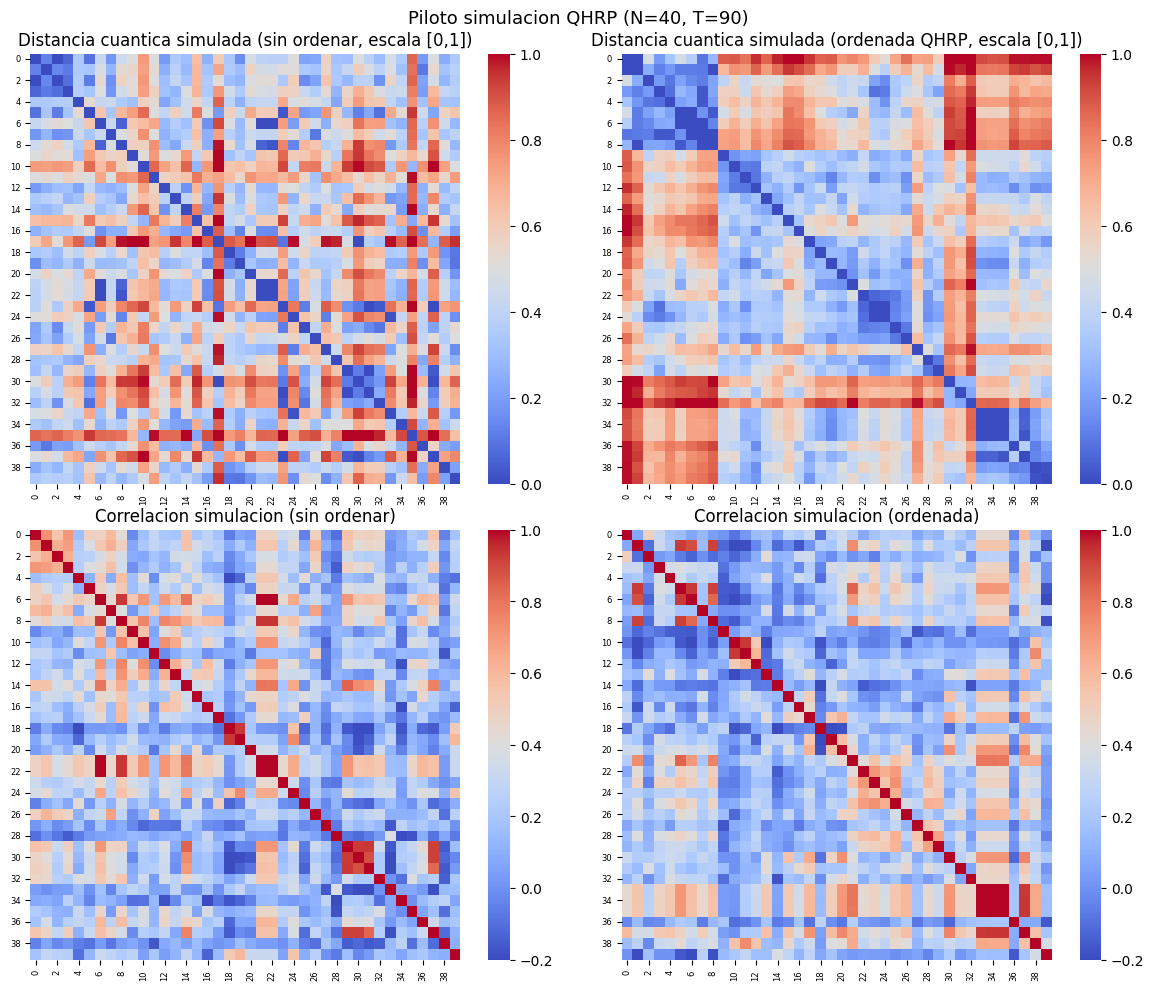

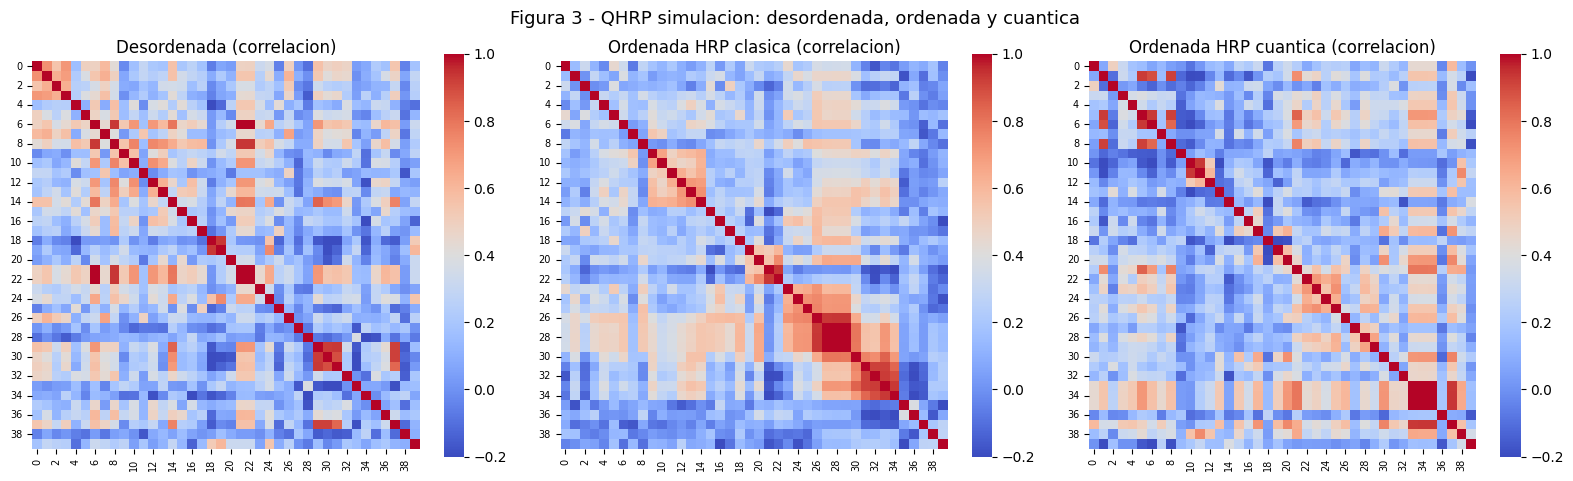

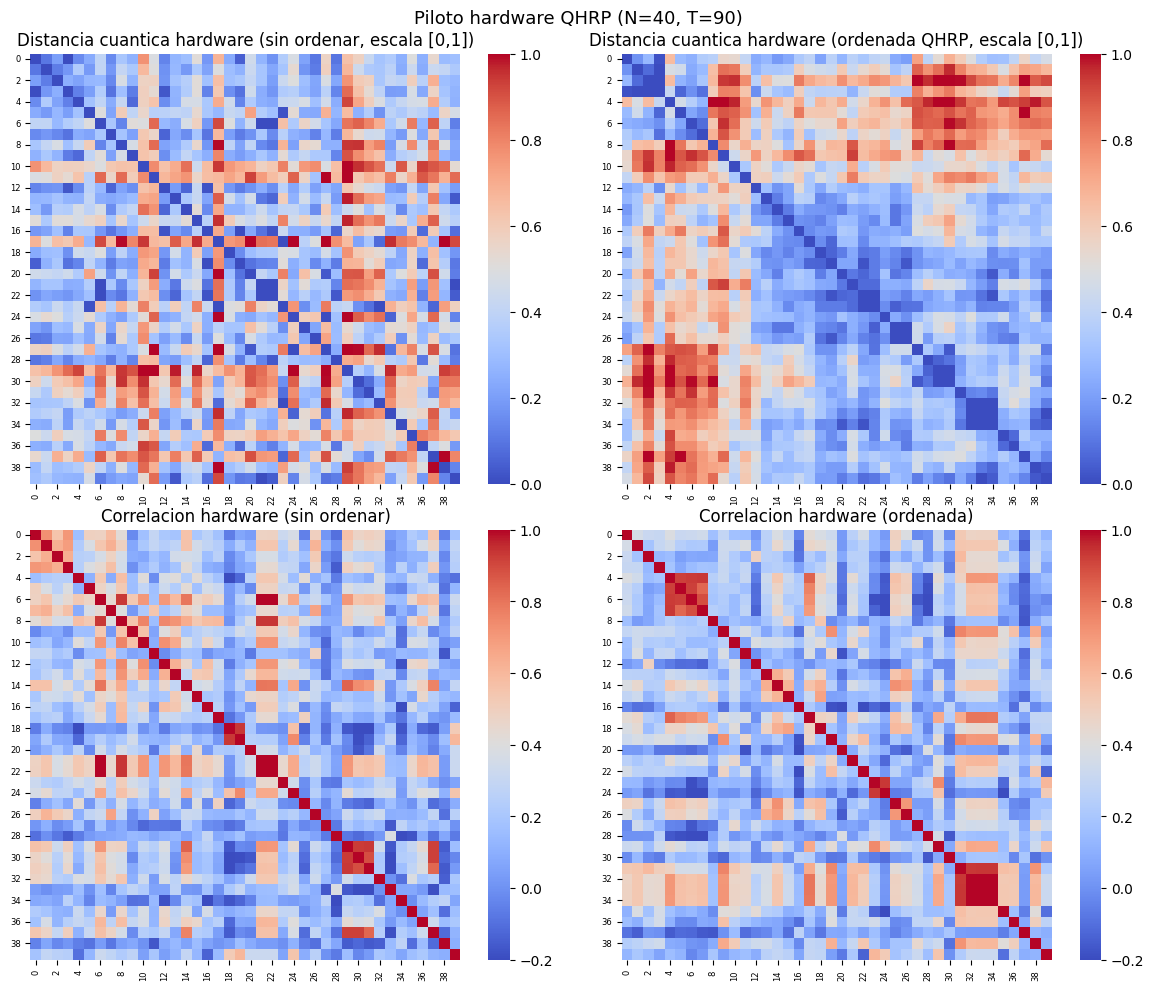

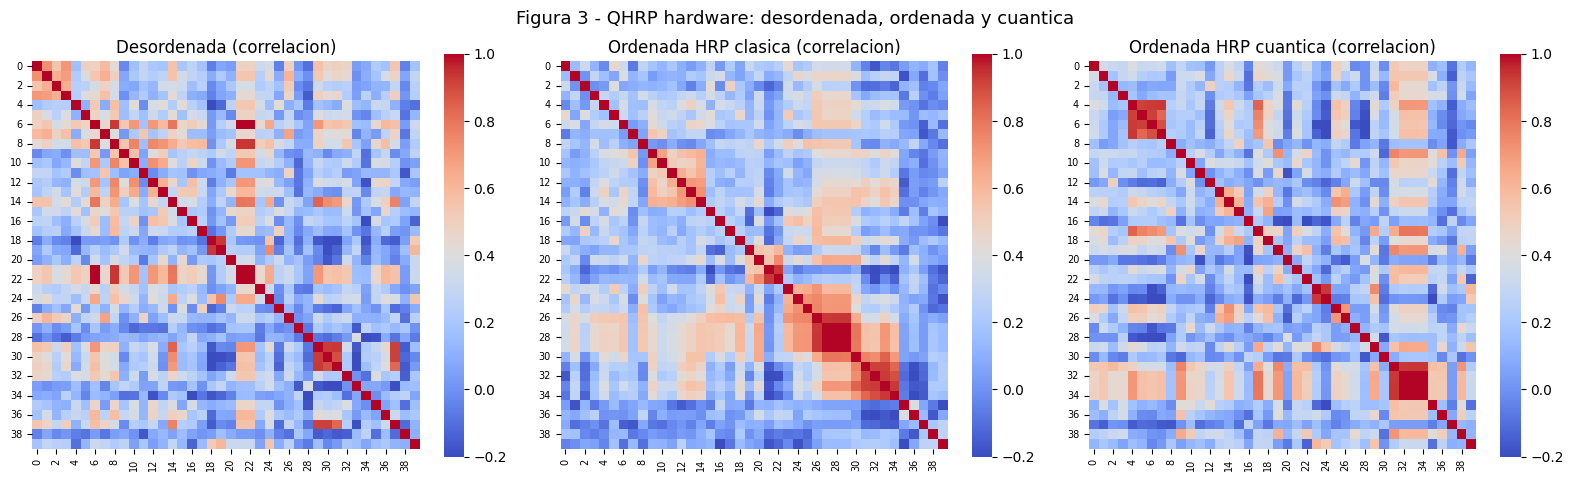

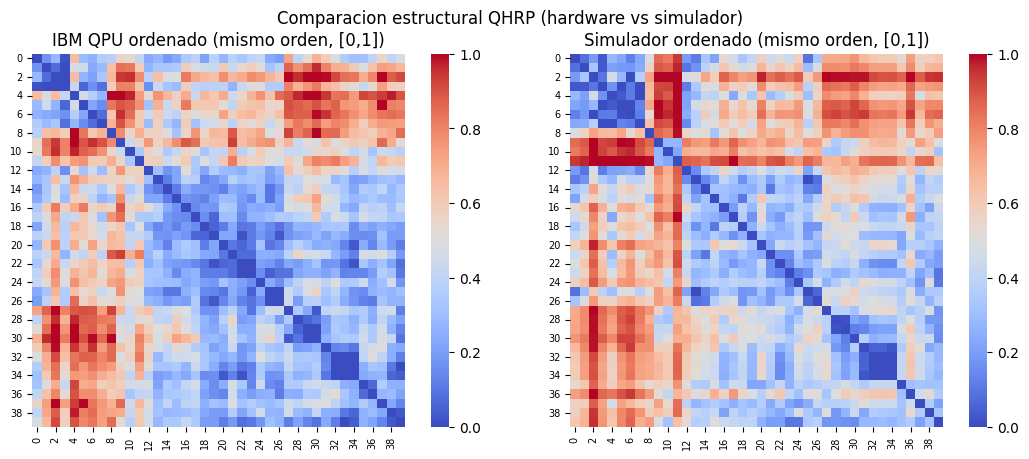

In [2]:
# Celda final comparativa: genera TODAS las imagenes (simulacion + hardware + comparacion)
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Hacer la celda autosuficiente por si se reinicia el kernel.
if os.path.abspath("./src") not in sys.path:
    sys.path.append(os.path.abspath("./src"))

from quantum_hrp_hardware import (
    counts_to_probability_vector,
    compute_distribution_distance_matrix,
    quantum_ordering_from_distance,
    average_density_matrix,
    compute_distance_matrix,
    quantum_ordering,
)


def _prepare_subset_40x90_if_needed():
    """Reconstruye returns_hw/features_hw si no estan en memoria (sin usar hardware)."""
    global alpha, returns_hw, features_hw, N_hw, T_hw, P_hw, selected_assets

    required = ["returns_hw", "features_hw", "N_hw", "T_hw", "P_hw", "selected_assets"]
    if all(k in globals() for k in required):
        return

    print("[Info] Reconstruyendo subconjunto 40x90 desde CSV/NPY (kernel limpio).")

    returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
    features = np.load("../../data/features.npy")

    orig_cols = returns.columns.tolist()
    returns = returns.apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any").dropna(axis=1, how="all")
    std = returns.std(axis=0)
    returns = returns.loc[:, std > 1e-8]
    surviving_idx = [orig_cols.index(c) for c in returns.columns]
    features = features[surviving_idx]

    target_assets = 40
    target_days = 90
    alpha = globals().get("alpha", 2.0)

    T_hw = min(target_days, returns.shape[0], features.shape[1])
    returns_recent = returns.tail(T_hw)

    prices = pd.read_csv("../../data/prices.csv", index_col=0, low_memory=False)
    volumes = pd.read_csv("../../data/volumes.csv", index_col=0, low_memory=False)
    prices.index = pd.to_datetime(prices.index, format="%Y-%m-%d", errors="coerce")
    volumes.index = pd.to_datetime(volumes.index, format="%Y-%m-%d", errors="coerce")
    prices = prices[~prices.index.isna()].apply(pd.to_numeric, errors="coerce")
    volumes = volumes[~volumes.index.isna()].apply(pd.to_numeric, errors="coerce")

    common_cols = [c for c in returns_recent.columns if (c in prices.columns and c in volumes.columns)]
    returns_recent_aligned = returns_recent[common_cols]
    prices_recent = prices.reindex(returns_recent_aligned.index).reindex(columns=common_cols)
    volumes_recent = volumes.reindex(returns_recent_aligned.index).reindex(columns=common_cols)

    dollar_volume = prices_recent * volumes_recent
    liq_score = dollar_volume.median(axis=0, skipna=True)
    liq_score = liq_score.replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)

    selected_assets = liq_score.index[: min(target_assets, len(liq_score))].tolist()

    if len(selected_assets) < target_assets:
        missing = target_assets - len(selected_assets)
        vol_score = returns_recent.std(axis=0).sort_values(ascending=False)
        fallback = [a for a in vol_score.index if a not in selected_assets][:missing]
        selected_assets = selected_assets + fallback

    selected_assets = selected_assets[: min(target_assets, len(selected_assets))]
    selected_idx = [returns.columns.get_loc(c) for c in selected_assets]

    returns_hw = returns_recent[selected_assets]
    features_hw = features[selected_idx][:, -T_hw:, :]
    N_hw, _, P_hw = features_hw.shape

    print(f"[Info] Subconjunto reconstruido: N={N_hw}, T={T_hw}, P={P_hw}")


def _load_or_recover_hardware_matrix():
    """Carga D_quantum_hardware de cache o la recupera desde jobs IBM ya completados."""
    expected_n = int(N_hw)
    expected_t = int(T_hw)
    expected_p = int(P_hw)

    cache_dir = Path("./results")
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"hardware_trial_cache_N{expected_n}_T{expected_t}_P{expected_p}.npz"

    if cache_path.exists():
        cache = np.load(cache_path, allow_pickle=True)
        d_cached = cache["D_quantum_hardware"]
        ord_cached = cache["order_hw"] if "order_hw" in cache.files else None
        print(f"[Info] Cargada matriz hardware desde cache: {cache_path}")
        return d_cached, ord_cached

    print("[Info] No hay cache local. Intentando recuperar matriz desde jobs IBM ya completados...")

    from qiskit_ibm_runtime import QiskitRuntimeService

    runtime_channel = globals().get("IBM_CHANNEL", "ibm_quantum_platform")
    runtime_account_name = globals().get("IBM_ACCOUNT_NAME", None)
    runtime_backend_name = globals().get("IBM_BACKEND_NAME", None)

    if runtime_account_name:
        service = QiskitRuntimeService(name=runtime_account_name)
    else:
        service = QiskitRuntimeService(channel=runtime_channel)

    jobs = service.jobs(limit=300)

    dist_candidates = []
    for j in jobs:
        st = str(j.status()).upper()
        if ("DONE" not in st) and ("COMPLETED" not in st):
            continue

        try:
            if runtime_backend_name is not None:
                jb = j.backend()
                jb_name = jb.name if hasattr(jb, "name") else str(jb)
                if jb_name != runtime_backend_name:
                    continue

            res = j.result()
            n_pubs = len(res)
            if n_pubs != expected_t:
                continue

            c0 = res[0].data.meas.get_counts()
            first_key = next(iter(c0))
            n_qubits = len(str(first_key).replace(" ", ""))
            if n_qubits != expected_p:
                continue

            probs = []
            for k in range(n_pubs):
                ck = res[k].data.meas.get_counts()
                shots_k = max(sum(ck.values()), 1)
                probs.append(
                    counts_to_probability_vector(
                        ck,
                        n_qubits=n_qubits,
                        shots=shots_k,
                    )
                )
            dist_candidates.append(np.mean(np.stack(probs, axis=0), axis=0))

            if len(dist_candidates) >= expected_n:
                break

        except Exception:
            continue

    if len(dist_candidates) < expected_n:
        raise RuntimeError(
            "No se pudo reconstruir D_quantum_hardware desde jobs completados ni cache local. "
            "Opciones: (1) ejecutar una vez la celda de hardware para generar cache local, "
            "o (2) aumentar limit en service.jobs(...) si tus jobs antiguos no aparecen entre los recientes."
        )

    # service.jobs devuelve los mas recientes primero; invertimos para aproximar orden temporal de envio.
    dist_hw_list = list(reversed(dist_candidates[:expected_n]))
    d_hw = compute_distribution_distance_matrix(dist_hw_list, metric="hellinger")
    ord_hw = quantum_ordering_from_distance(d_hw)

    np.savez(cache_path, D_quantum_hardware=d_hw, order_hw=ord_hw)
    print(f"[Info] Matriz hardware recuperada desde Runtime y guardada en cache: {cache_path}")
    return d_hw, ord_hw


def robust_rescale_01(mat, q_low=1, q_high=99):
    off = mat[np.triu_indices_from(mat, 1)]
    lo = np.percentile(off, q_low)
    hi = np.percentile(off, q_high)
    if hi <= lo:
        return np.zeros_like(mat)
    out = (mat - lo) / (hi - lo)
    return np.clip(out, 0, 1)


def classical_hrp_order_from_corr(corr_matrix):
    dist = np.sqrt((1 - corr_matrix) / 2.0)
    dist = 0.5 * (dist + dist.T)
    np.fill_diagonal(dist, 0.0)
    dist = np.nan_to_num(dist)
    Z = linkage(squareform(dist, checks=False), method="single")
    return leaves_list(Z)


_prepare_subset_40x90_if_needed()

# ---- Bloque A: simulacion (equivalente celda 8) ----
if "D_quantum_sim" not in globals() or "order_sim" not in globals() or "D_quantum_sim_ord" not in globals():
    print("[Info] Recalculando simulacion ideal para generar figuras completas.")
    rho_sim_list = [average_density_matrix(features_hw[i], alpha=alpha) for i in range(N_hw)]
    D_quantum_sim = compute_distance_matrix(rho_sim_list)
    order_sim = quantum_ordering(D_quantum_sim)
    D_quantum_sim_ord = D_quantum_sim[np.ix_(order_sim, order_sim)]

D_sim_raw = D_quantum_sim
D_sim_ord = D_quantum_sim_ord
corr_sim_raw = np.corrcoef(returns_hw.values, rowvar=False)
order_classical_sim = classical_hrp_order_from_corr(corr_sim_raw)
corr_sim_classical = corr_sim_raw[np.ix_(order_classical_sim, order_classical_sim)]
corr_sim_ord = corr_sim_raw[np.ix_(order_sim, order_sim)]
D_sim_raw_vis = robust_rescale_01(D_sim_raw)
D_sim_ord_vis = robust_rescale_01(D_sim_ord)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.heatmap(D_sim_raw_vis, cmap="coolwarm", vmin=0, vmax=1, square=True, cbar=True, ax=axes[0, 0])
axes[0, 0].set_title("Distancia cuantica simulada (sin ordenar, escala [0,1])")
axes[0, 0].tick_params(labelsize=6)

sns.heatmap(D_sim_ord_vis, cmap="coolwarm", vmin=0, vmax=1, square=True, cbar=True, ax=axes[0, 1])
axes[0, 1].set_title("Distancia cuantica simulada (ordenada QHRP, escala [0,1])")
axes[0, 1].tick_params(labelsize=6)

sns.heatmap(corr_sim_raw, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=axes[1, 0])
axes[1, 0].set_title("Correlacion simulacion (sin ordenar)")
axes[1, 0].tick_params(labelsize=6)

sns.heatmap(corr_sim_ord, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=axes[1, 1])
axes[1, 1].set_title("Correlacion simulacion (ordenada)")
axes[1, 1].tick_params(labelsize=6)

plt.suptitle("Piloto simulacion QHRP (N=40, T=90)", fontsize=13)
plt.tight_layout()
plt.show()

# Figura adicional de 3 paneles: desordenada, ordenada y cuantica (simulacion)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sns.heatmap(corr_sim_raw, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=axes[0])
axes[0].set_title("Desordenada (correlacion)")
axes[0].tick_params(labelsize=7)

sns.heatmap(corr_sim_classical, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=axes[1])
axes[1].set_title("Ordenada HRP clasica (correlacion)")
axes[1].tick_params(labelsize=7)

sns.heatmap(corr_sim_ord, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=axes[2])
axes[2].set_title("Ordenada HRP cuantica (correlacion)")
axes[2].tick_params(labelsize=7)

plt.suptitle("Figura 3 - QHRP simulacion: desordenada, ordenada y cuantica", fontsize=13)
plt.tight_layout()
plt.show()

# ---- Bloque B: hardware ----
if "D_quantum_hardware" not in globals():
    D_quantum_hardware, order_hw_from_recovery = _load_or_recover_hardware_matrix()
    if "order_hw" not in globals() and order_hw_from_recovery is not None:
        order_hw = np.array(order_hw_from_recovery, dtype=int)

if "order_hw" not in globals():
    order_hw = quantum_ordering_from_distance(D_quantum_hardware)

D_hw_raw = D_quantum_hardware
D_hw_ord = D_quantum_hardware[np.ix_(order_hw, order_hw)]
corr_hw_raw = np.corrcoef(returns_hw.values, rowvar=False)
order_classical_hw = classical_hrp_order_from_corr(corr_hw_raw)
corr_hw_classical = corr_hw_raw[np.ix_(order_classical_hw, order_classical_hw)]
corr_hw_ord = corr_hw_raw[np.ix_(order_hw, order_hw)]
D_hw_raw_vis = robust_rescale_01(D_hw_raw)
D_hw_ord_vis = robust_rescale_01(D_hw_ord)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.heatmap(D_hw_raw_vis, cmap="coolwarm", vmin=0, vmax=1, square=True, cbar=True, ax=axes[0, 0])
axes[0, 0].set_title("Distancia cuantica hardware (sin ordenar, escala [0,1])")
axes[0, 0].tick_params(labelsize=6)

sns.heatmap(D_hw_ord_vis, cmap="coolwarm", vmin=0, vmax=1, square=True, cbar=True, ax=axes[0, 1])
axes[0, 1].set_title("Distancia cuantica hardware (ordenada QHRP, escala [0,1])")
axes[0, 1].tick_params(labelsize=6)

sns.heatmap(corr_hw_raw, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=axes[1, 0])
axes[1, 0].set_title("Correlacion hardware (sin ordenar)")
axes[1, 0].tick_params(labelsize=6)

sns.heatmap(corr_hw_ord, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=axes[1, 1])
axes[1, 1].set_title("Correlacion hardware (ordenada)")
axes[1, 1].tick_params(labelsize=6)

plt.suptitle("Piloto hardware QHRP (N=40, T=90)", fontsize=13)
plt.tight_layout()
plt.show()

# Figura adicional de 3 paneles: desordenada, ordenada y cuantica (hardware)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sns.heatmap(corr_hw_raw, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=axes[0])
axes[0].set_title("Desordenada (correlacion)")
axes[0].tick_params(labelsize=7)

sns.heatmap(corr_hw_classical, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=axes[1])
axes[1].set_title("Ordenada HRP clasica (correlacion)")
axes[1].tick_params(labelsize=7)

sns.heatmap(corr_hw_ord, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=axes[2])
axes[2].set_title("Ordenada HRP cuantica (correlacion)")
axes[2].tick_params(labelsize=7)

plt.suptitle("Figura 3 - QHRP hardware: desordenada, ordenada y cuantica", fontsize=13)
plt.tight_layout()
plt.show()

# ---- Bloque C: comparacion directa hardware vs simulador ----
# Usamos el mismo orden de activos para comparar estructura de bloques de forma justa.
order_ref = order_hw
D_hw_cmp = D_quantum_hardware[np.ix_(order_ref, order_ref)]
D_sim_cmp = D_quantum_sim[np.ix_(order_ref, order_ref)]

D_hw_vis = robust_rescale_01(D_hw_cmp)
D_sim_vis = robust_rescale_01(D_sim_cmp)
D_diff = np.abs(D_hw_vis - D_sim_vis)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(D_hw_vis, cmap="coolwarm", vmin=0, vmax=1, square=True, cbar=True, ax=axes[0])
axes[0].set_title("IBM QPU ordenado (mismo orden, [0,1])")
axes[0].tick_params(labelsize=7)

sns.heatmap(D_sim_vis, cmap="coolwarm", vmin=0, vmax=1, square=True, cbar=True, ax=axes[1])
axes[1].set_title("Simulador ordenado (mismo orden, [0,1])")
axes[1].tick_params(labelsize=7)

plt.suptitle("Comparacion estructural QHRP (hardware vs simulador)")
plt.tight_layout()
plt.show()